# Wind Power Forecasting — Identification & Assumptions Notebook


In [1]:

# =============================
# 0) Setup
# =============================
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.nonparametric.smoothers_lowess import lowess

pd.set_option("display.max_columns", 200)

def _find_data_file():
    """
    Tries a few common locations. Edit here if needed.
    """
    candidates = [
        Path("../data/cex4WindDataInterpolated.csv"),
        Path("cex4WindDataInterpolated.csv"),
        Path.home() / "cex4WindDataInterpolated.csv",
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        "Could not find cex4WindDataInterpolated.csv. "
        "Place it in ./data/ or the notebook folder, or edit _find_data_file()."
    )

def load_wind_data(path=None) -> pd.DataFrame:
    if path is None:
        path = _find_data_file()
    df = pd.read_csv(path)
    # Time column in file is UTC timestamp string
    df["t"] = pd.to_datetime(df["t"], utc=True, errors="coerce")
    df = df.sort_values("t").reset_index(drop=True)
    return df

def add_circular(df: pd.DataFrame, wd_col: str) -> pd.DataFrame:
    ang = np.deg2rad(df[wd_col].astype(float))
    df[f"{wd_col}_sin"] = np.sin(ang)
    df[f"{wd_col}_cos"] = np.cos(ang)
    return df

def add_hour_of_day(df: pd.DataFrame) -> pd.DataFrame:
    # Use UTC hour for diurnal structure
    df["hour"] = df["t"].dt.hour
    return df

def rolling_mean_var(x: pd.Series, window: int) -> pd.DataFrame:
    return pd.DataFrame({
        "mean": x.rolling(window, min_periods=window).mean(),
        "var":  x.rolling(window, min_periods=window).var(),
    })

def lagged_scatter(x: pd.Series, lag: int, ax=None, max_points: int = 20000):
    if ax is None:
        ax = plt.gca()
    x0 = x.values[lag:]
    x1 = x.values[:-lag]
    m = min(len(x0), max_points)
    if len(x0) > m:
        idx = np.random.default_rng(0).choice(len(x0), size=m, replace=False)
        x0, x1 = x0[idx], x1[idx]
    ax.scatter(x1, x0, s=6, alpha=0.35)
    ax.set_xlabel(f"x[t-{lag}]")
    ax.set_ylabel("x[t]")
    ax.set_title(f"Lagged scatter (lag={lag})")


## 1. Data overview (minimal, purposeful)

We only show plots that directly support identification or assumption validation.

In [2]:

df = load_wind_data()

# Add circular features for all wind-direction horizons present (Wd1..Wd3)
for k in [1, 2, 3]:
    if f"Wd{k}" in df.columns:
        df = add_circular(df, f"Wd{k}")

df = add_hour_of_day(df)

df.head()


,t,toy,p,Ws1,Wd1,T1,Ws2,Wd2,T2,Ws3,Wd3,T3,Wd1_sin,Wd1_cos,Wd2_sin,Wd2_cos,Wd3_sin,Wd3_cos,hour
0,1999-01-01 03:00:00+00:00,0.125,1.267,4.9,135.0,275.8,4.9,135.0,275.8,4.9,135.0,275.8,0.707107,-0.707107,0.707107,-0.707107,0.707107,-0.707107,3
1,1999-01-01 04:00:00+00:00,0.167,1.515,5.0,126.9,275.8,5.0,126.9,275.8,5.0,126.9,275.8,0.799685,-0.600420,0.799685,-0.600420,0.799685,-0.600420,4
2,1999-01-01 05:00:00+00:00,0.208,1.915,5.9,135.7,275.5,5.9,135.7,275.5,5.9,135.7,275.5,0.698415,-0.715693,0.698415,-0.715693,0.698415,-0.715693,5
3,1999-01-01 06:00:00+00:00,0.250,1.613,5.3,146.6,275.0,5.3,146.6,275.0,5.3,146.6,275.0,0.550481,-0.834848,0.550481,-0.834848,0.550481,-0.834848,6
4,1999-01-01 07:00:00+00:00,0.292,1.776,6.1,117.4,274.5,5.9,130.2,274.8,5.9,130.2,274.8,0.887815,-0.460200,0.763796,-0.645458,0.763796,-0.645458,7


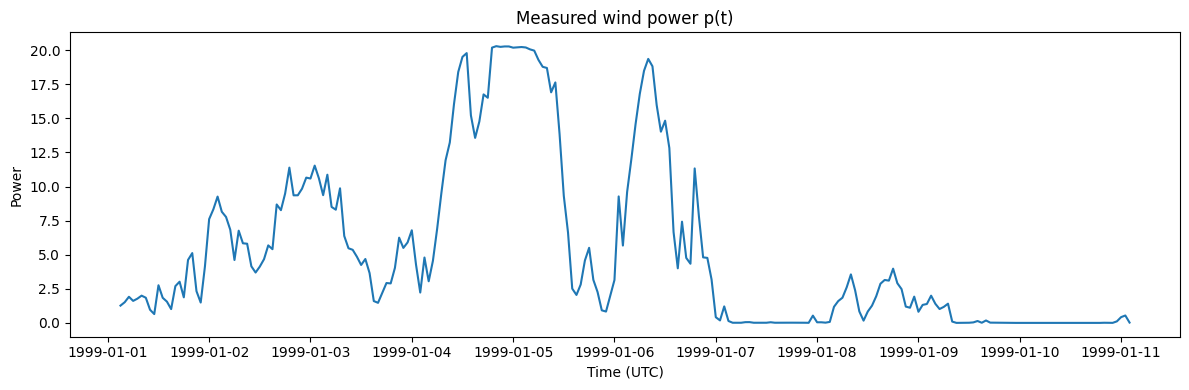

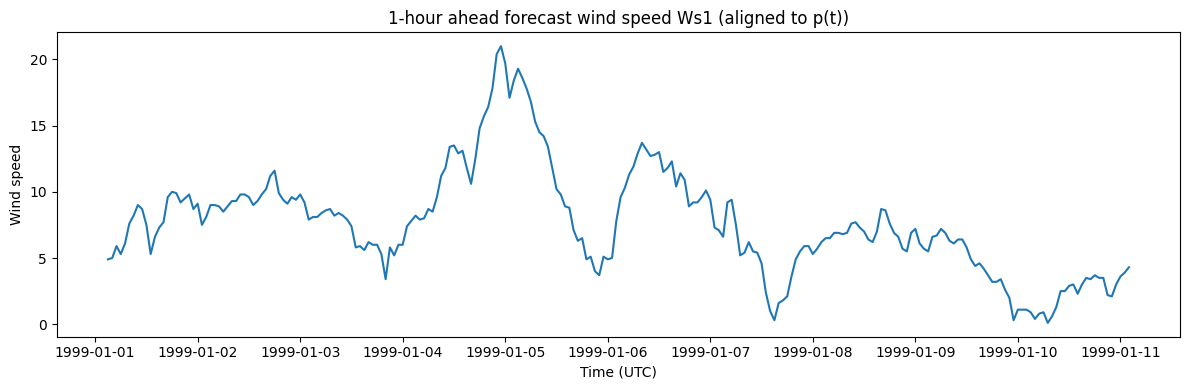

In [3]:

# -----------------------------
# Plot: power and key drivers
# -----------------------------
# Limit to first 10 days for clarity
df_plot = df[df["t"] < df["t"].min() + pd.Timedelta(days=10)]
plt.figure(figsize=(12,4))
plt.plot(df_plot["t"], df_plot["p"])
plt.title("Measured wind power p(t)")
plt.xlabel("Time (UTC)")
plt.ylabel("Power")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(df_plot["t"], df_plot["Ws1"])
plt.title("1-hour ahead forecast wind speed Ws1 (aligned to p(t))")
plt.xlabel("Time (UTC)")
plt.ylabel("Wind speed")
plt.tight_layout()
plt.show()


**Finding.** The raw series shows strong short-term variability with visually apparent persistence, motivating AR terms and careful residual checks.

## 2. Identification findings (Lecture Notes Chapter 3-driven)

Each diagnostic is shown as a plot and followed by exactly one interpretive sentence with a modelling implication.

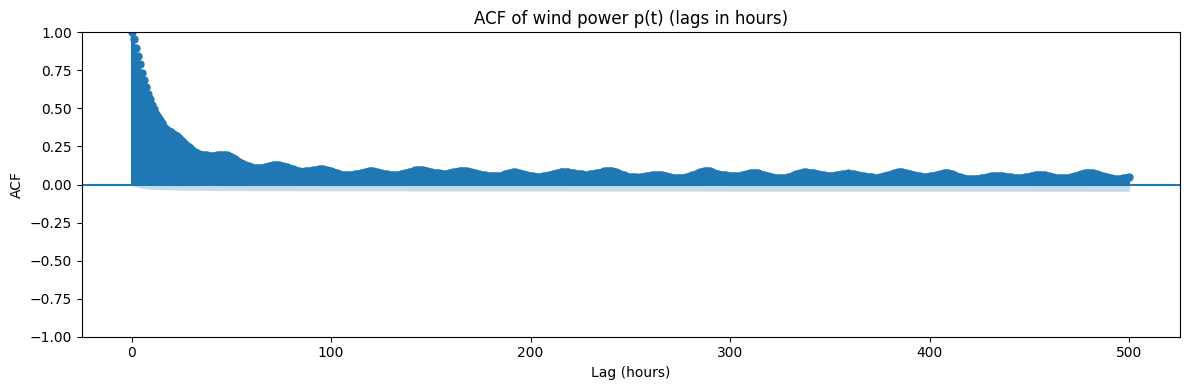

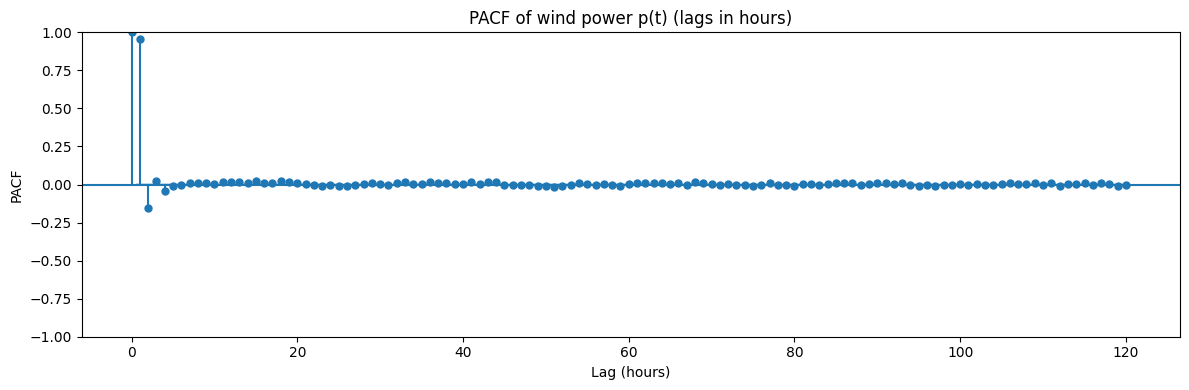

In [4]:

x = df["p"].astype(float).dropna()

plt.figure(figsize=(12,4))
plot_acf(x, lags=500, ax=plt.gca())
plt.title("ACF of wind power p(t) (lags in hours)")
plt.xlabel("Lag (hours)")
plt.ylabel("ACF")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(x, lags=120, ax=plt.gca(), method="ywm")
plt.title("PACF of wind power p(t) (lags in hours)")
plt.xlabel("Lag (hours)")
plt.ylabel("PACF")
plt.tight_layout()
plt.show()


**Finding.** The ACF decays slowly and the PACF indicates a small set of dominant short lags, suggesting an AR component with a few hours of memory.

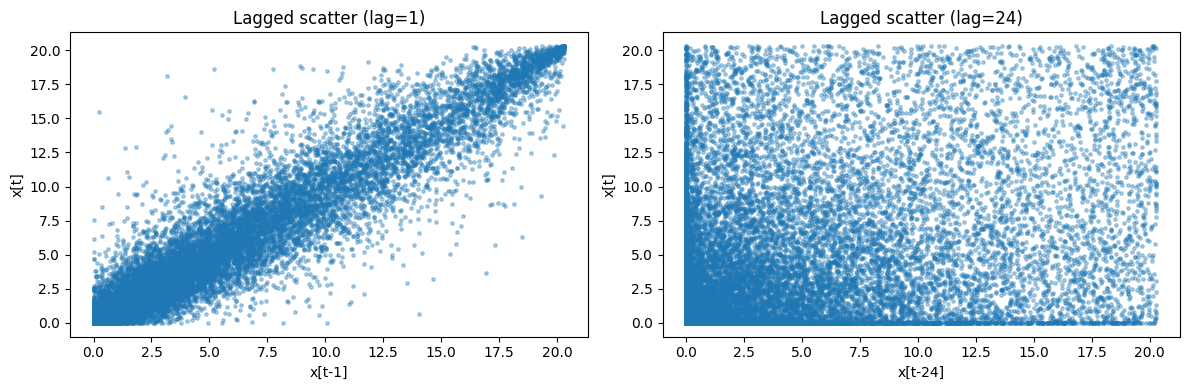

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(12,4))
lagged_scatter(df["p"].astype(float), lag=1, ax=axes[0])
lagged_scatter(df["p"].astype(float), lag=24, ax=axes[1])
plt.tight_layout()
plt.show()


**Finding.**  Lagged scatter at lag 1 shows strong serial dependence and level-dependent spread (suggesting heteroskedasticity / mild nonlinearity). The lag 24 scatter does not show a clear daily echo; diurnal structure should instead be assessed via the ACF at seasonal lags (24, 48, …) and/or power by hour-of-day."

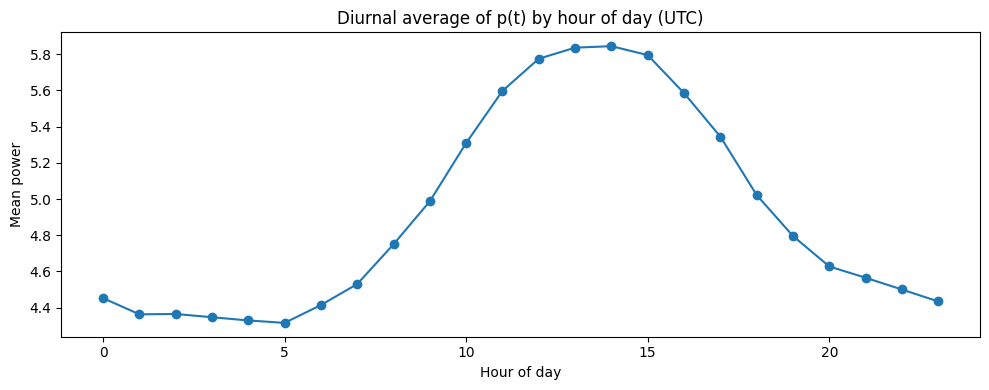

In [6]:

g = df.groupby("hour")["p"].mean()

plt.figure(figsize=(10,4))
plt.plot(g.index, g.values, marker="o")
plt.title("Diurnal average of p(t) by hour of day (UTC)")
plt.xlabel("Hour of day")
plt.ylabel("Mean power")
plt.tight_layout()
plt.show()


**Finding.** A systematic hour-of-day pattern implies diurnal seasonality, so include a diurnal term (or allow time-varying coefficients) to avoid systematic residual structure.

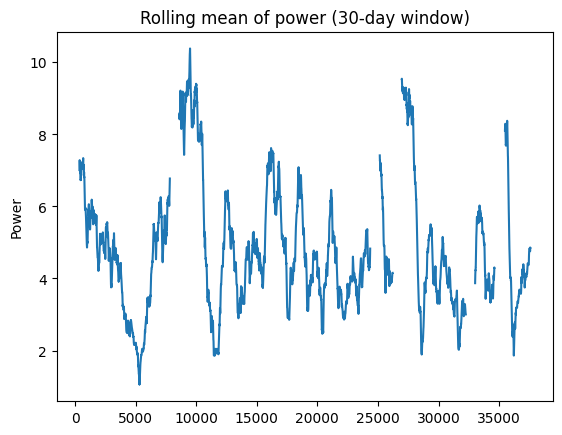

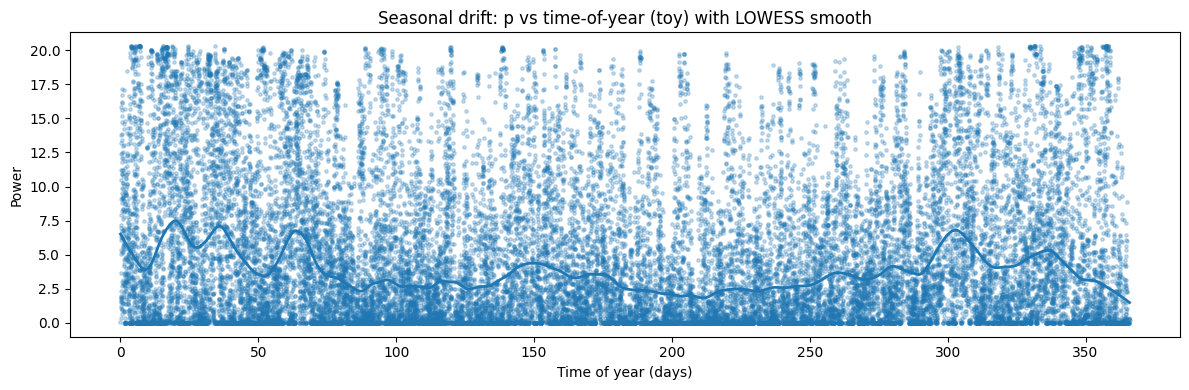

In [7]:

toy = df["toy"].astype(float)
p = df["p"].astype(float)

# Rolling mean to confirm slow time scale of drift
p.rolling(window=24*30, center=True).mean().plot(
    title="Rolling mean of power (30-day window)",
    ylabel="Power"
)


mask = toy.notna() & p.notna()
toy_m = toy[mask].values
p_m = p[mask].values

# subsample for speed
m = min(len(toy_m), 30000)
if len(toy_m) > m:
    idx = np.random.default_rng(1).choice(len(toy_m), size=m, replace=False)
    toy_m, p_m = toy_m[idx], p_m[idx]

smth = lowess(p_m, toy_m, frac=0.05, return_sorted=True)

plt.figure(figsize=(12,4))
plt.scatter(toy_m, p_m, s=6, alpha=0.25)
plt.plot(smth[:,0], smth[:,1], linewidth=2)
plt.title("Seasonal drift: p vs time-of-year (toy) with LOWESS smooth")
plt.xlabel("Time of year (days)")
plt.ylabel("Power")
plt.tight_layout()
plt.show()


**Finding.** The conditional mean of power drifts with time-of-year, supporting seasonal terms or adaptive parameters to track slow environmental changes.

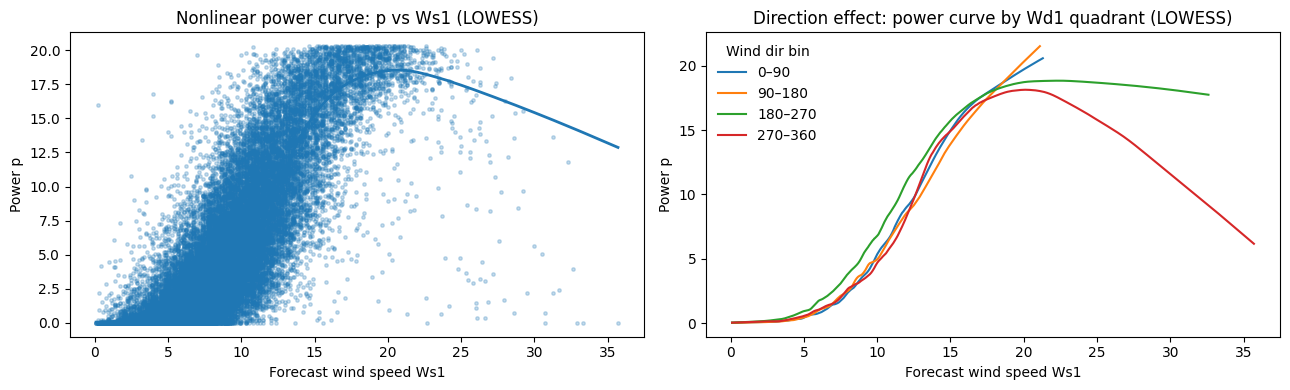

C:\Users\tamas\AppData\Local\Temp\ipykernel_24180\218857762.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Ws_bin", "Wd1_sector"])["p"].mean().unstack().plot(


<Axes: title={'center': 'Mean power by wind speed bin and direction sector'}, xlabel='Ws_bin', ylabel='Mean power'>

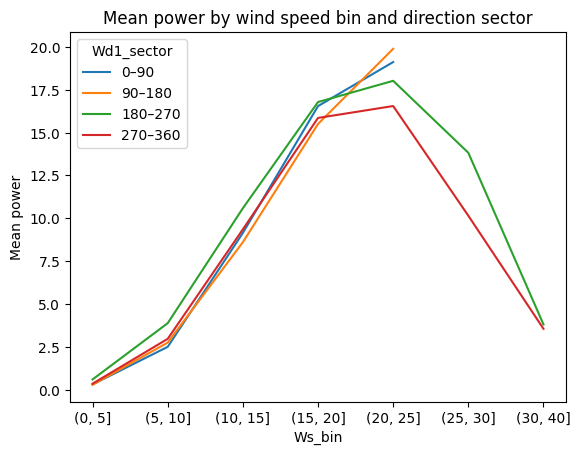

In [8]:

ws = df["Ws1"].astype(float)
wd = df["Wd1"].astype(float)
p = df["p"].astype(float)
mask = ws.notna() & wd.notna() & p.notna()
ws_m, wd_m, p_m = ws[mask], wd[mask], p[mask]

# Subsample for readability
m = min(len(ws_m), 40000)
if len(ws_m) > m:
    idx = np.random.default_rng(2).choice(len(ws_m), size=m, replace=False)
    ws_s, wd_s, p_s = ws_m.iloc[idx], wd_m.iloc[idx], p_m.iloc[idx]
else:
    ws_s, wd_s, p_s = ws_m, wd_m, p_m

fig, axes = plt.subplots(1, 2, figsize=(13,4))

axes[0].scatter(ws_s, p_s, s=6, alpha=0.25)
smth = lowess(p_s.values, ws_s.values, frac=0.05, return_sorted=True)
axes[0].plot(smth[:,0], smth[:,1], linewidth=2)
axes[0].set_title("Nonlinear power curve: p vs Ws1 (LOWESS)")
axes[0].set_xlabel("Forecast wind speed Ws1")
axes[0].set_ylabel("Power p")

bins = [0, 90, 180, 270, 360]
labels = ["0–90", "90–180", "180–270", "270–360"]
dirbin = pd.cut(wd_s % 360, bins=bins, labels=labels, include_lowest=True, right=False)
for lab in labels:
    sub = (dirbin == lab)
    if sub.sum() < 200:
        continue
    sm = lowess(p_s[sub].values, ws_s[sub].values, frac=0.08, return_sorted=True)
    axes[1].plot(sm[:,0], sm[:,1], label=lab)

axes[1].set_title("Direction effect: power curve by Wd1 quadrant (LOWESS)")
axes[1].set_xlabel("Forecast wind speed Ws1")
axes[1].set_ylabel("Power p")
axes[1].legend(title="Wind dir bin", frameon=False)

plt.tight_layout()
plt.show()

# Mean power by wind speed bin and direction sector
df["Ws_bin"] = pd.cut(df["Ws1"], bins=[0,5,10,15,20,25,30,40])
df["Wd1_sector"] = pd.cut(df["Wd1"] % 360, bins=[0, 90, 180, 270, 360], labels=["0–90", "90–180", "180–270", "270–360"], include_lowest=True, right=False)
df.groupby(["Ws_bin", "Wd1_sector"])["p"].mean().unstack().plot(
    title="Mean power by wind speed bin and direction sector",
    ylabel="Mean power"
)



**Finding.** Power depends nonlinearly on wind speed and shifts with wind direction, so ARX models should include nonlinear speed terms and circular direction features (sin/cos) or piecewise effects.

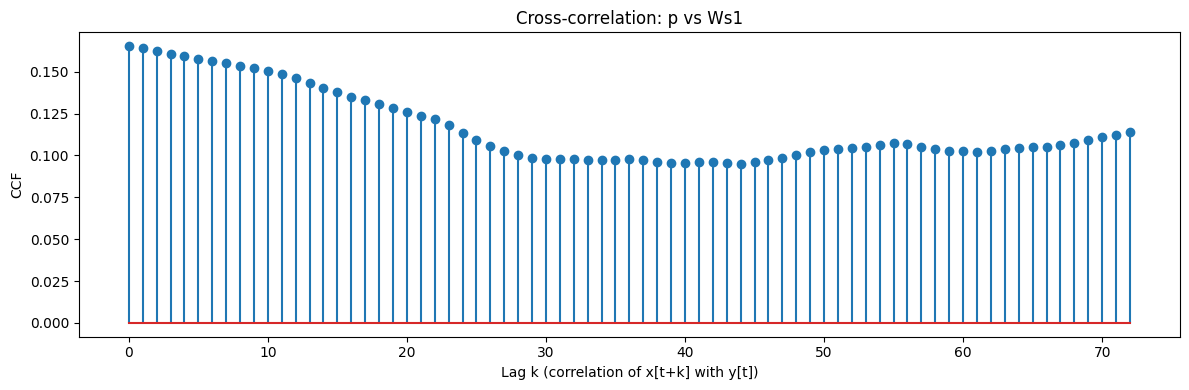

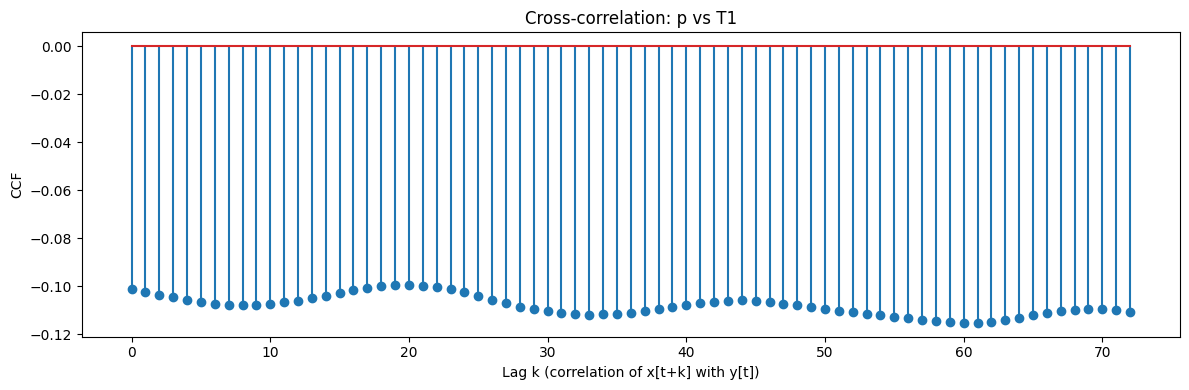

In [9]:

from statsmodels.tsa.stattools import ccf

def plot_ccf(x, y, nlags=72, title=""):
    x = pd.Series(x).astype(float).dropna()
    y = pd.Series(y).astype(float).dropna()
    n = min(len(x), len(y))
    x, y = x.iloc[-n:], y.iloc[-n:]
    vals = ccf(x, y)[:nlags+1]
    plt.figure(figsize=(12,4))
    plt.stem(range(len(vals)), vals)
    plt.title(title)
    plt.xlabel("Lag k (correlation of x[t+k] with y[t])")
    plt.ylabel("CCF")
    plt.tight_layout()
    plt.show()

plot_ccf(df["p"], df["Ws1"], nlags=72, title="Cross-correlation: p vs Ws1")
if "T1" in df.columns:
    plot_ccf(df["p"], df["T1"], nlags=72, title="Cross-correlation: p vs T1")


**Finding.** Wind speed forecasts show strong contemporaneous cross-dependence with power, supporting Ws as a primary exogenous driver in ARX (with careful interpretation due to autocorrelation).

## 3. Assumption checks by model class

### 3.1 Linear AR / ARX models

We test weak stationarity, linearity, identifiable lag structure, and residual whiteness/homoskedasticity using a *simple diagnostic ARX* fit.

In [10]:

# -----------------------------
# Diagnostic ARX fit (for residual diagnostics only)
# -----------------------------
L = 24  # enough to capture daily echo in diagnostics

work = df.copy()
work["p"] = work["p"].astype(float)

for lag in range(1, L+1):
    work[f"p_lag{lag}"] = work["p"].shift(lag)

X_cols = [f"p_lag{lag}" for lag in range(1, L+1)]
if "Ws1" in work.columns: X_cols.append("Ws1")
if "Wd1_sin" in work.columns: X_cols += ["Wd1_sin","Wd1_cos"]
if "T1" in work.columns: X_cols.append("T1")

work = work.dropna(subset=["p"] + X_cols).reset_index(drop=True)

n = len(work)
train_end = int(0.7 * n)
import statsmodels.api as sm
X_train = sm.add_constant(work.loc[:train_end-1, X_cols])
y_train = work.loc[:train_end-1, "p"]
ols = sm.OLS(y_train, X_train).fit()

X_all = sm.add_constant(work[X_cols])
work["p_hat"] = ols.predict(X_all)
work["resid"] = work["p"] - work["p_hat"]

ols.summary().tables[0]


Dep. Variable:,p,R-squared:,0.920
Model:,OLS,Adj. R-squared:,0.920
Method:,Least Squares,F-statistic:,1.039e+04
Date:,"Thu, 18 Dec 2025",Prob (F-statistic):,0.00
Time:,18:11:10,Log-Likelihood:,-47291.
No. Observations:,25300,AIC:,9.464e+04
Df Residuals:,25271,BIC:,9.488e+04
Df Model:,28,,
Covariance Type:,nonrobust,,


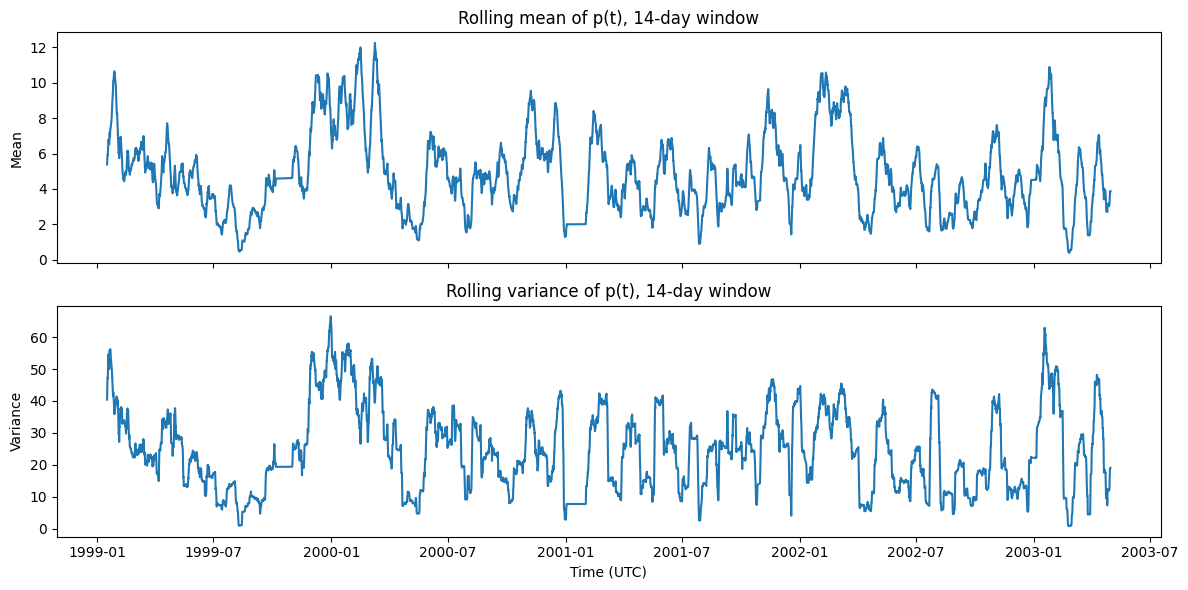

In [11]:

roll = rolling_mean_var(work["p"], window=24*14)  # 14 days

fig, ax = plt.subplots(2,1, figsize=(12,6), sharex=True)
ax[0].plot(work["t"], roll["mean"])
ax[0].set_title("Rolling mean of p(t), 14-day window")
ax[0].set_ylabel("Mean")

ax[1].plot(work["t"], roll["var"])
ax[1].set_title("Rolling variance of p(t), 14-day window")
ax[1].set_ylabel("Variance")
ax[1].set_xlabel("Time (UTC)")

plt.tight_layout()
plt.show()


**Assumption (weak stationarity).** Partially satisfied: rolling moments drift, so strict stationarity is doubtful and adaptive/seasonal components are justified.

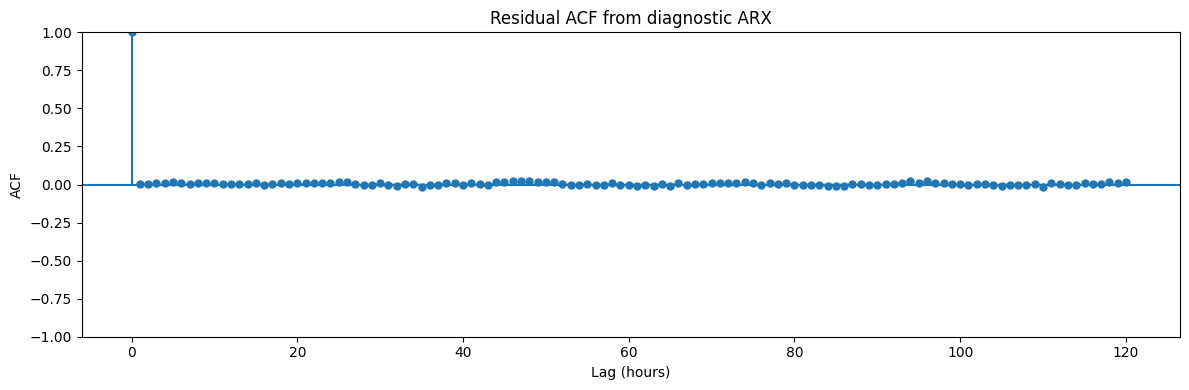

,lb_stat,lb_pvalue
24,64.292994,1.544605e-05
48,177.639373,9.062749e-17
72,247.959212,3.560970e-21


In [12]:

e = work["resid"].astype(float)

plt.figure(figsize=(12,4))
plot_acf(e, lags=120, ax=plt.gca())
plt.title("Residual ACF from diagnostic ARX")
plt.xlabel("Lag (hours)")
plt.ylabel("ACF")
plt.tight_layout()
plt.show()

lb = acorr_ljungbox(e.dropna(), lags=[24, 48, 72], return_df=True)
lb


**Assumption (residual whiteness / no remaining autocorrelation).** Evaluate via Ljung–Box: if p-values are small, the ARX lag structure is insufficient and more dynamics or adaptive terms are needed.

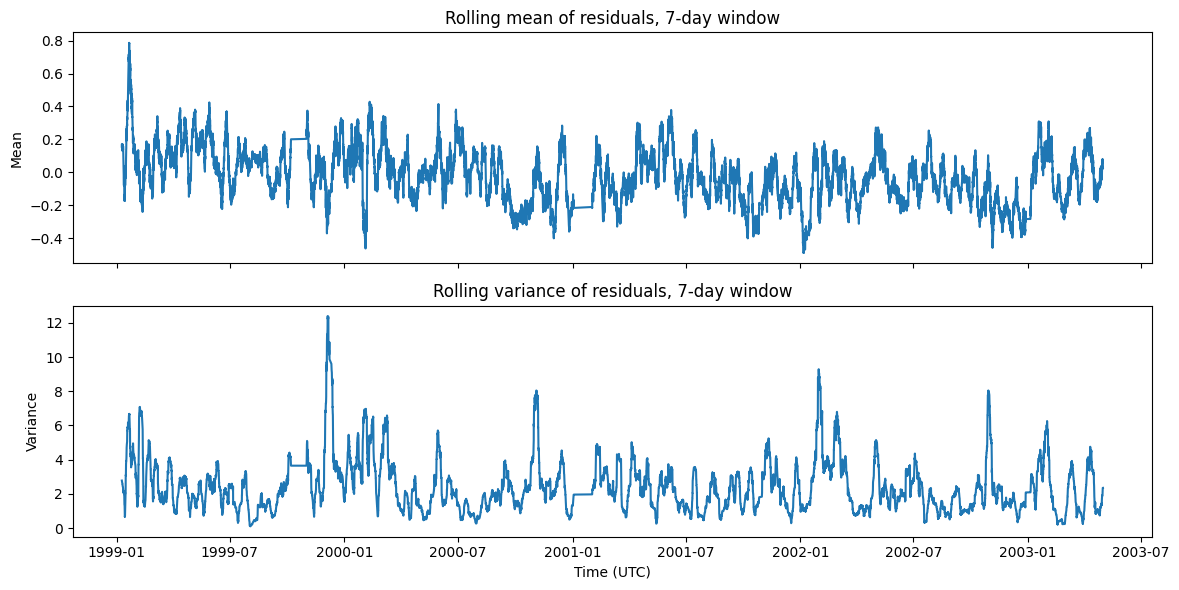

(3424.6007429626907, 0.0, 157.52894229772582, 0.0)

In [13]:

roll_e = rolling_mean_var(e, window=24*7)  # 7 days

fig, ax = plt.subplots(2,1, figsize=(12,6), sharex=True)
ax[0].plot(work["t"], roll_e["mean"])
ax[0].set_title("Rolling mean of residuals, 7-day window")
ax[0].set_ylabel("Mean")

ax[1].plot(work["t"], roll_e["var"])
ax[1].set_title("Rolling variance of residuals, 7-day window")
ax[1].set_ylabel("Variance")
ax[1].set_xlabel("Time (UTC)")

plt.tight_layout()
plt.show()

arch_lm = het_arch(e.dropna(), nlags=24)
arch_lm

**Assumption (approx. homoskedasticity).** If rolling variance shifts and ARCH p-values are small, homoskedasticity is violated and regime/variance modelling becomes relevant.

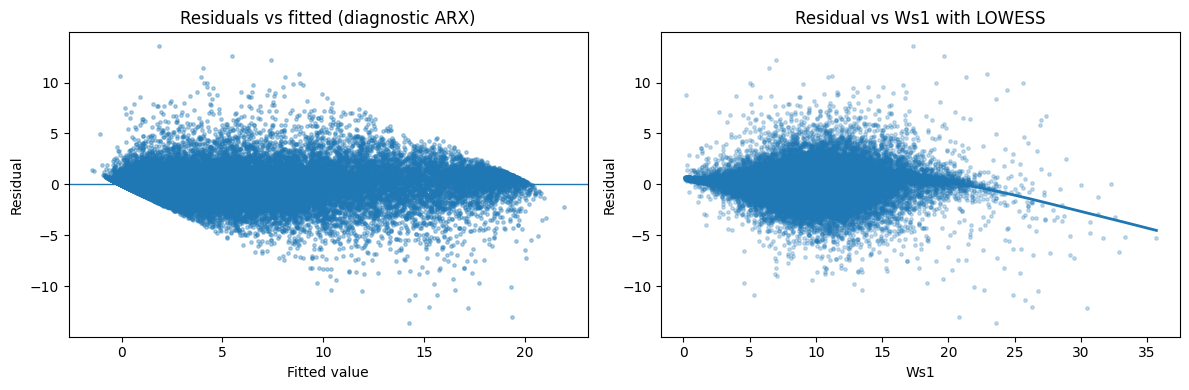

In [14]:

fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].scatter(work["p_hat"], work["resid"], s=6, alpha=0.35)
ax[0].axhline(0, linewidth=1)
ax[0].set_title("Residuals vs fitted (diagnostic ARX)")
ax[0].set_xlabel("Fitted value")
ax[0].set_ylabel("Residual")

if "Ws1" in work.columns:
    xs = work["Ws1"].astype(float).values
    ys = work["resid"].astype(float).values
    smth = lowess(ys, xs, frac=0.06, return_sorted=True)
    ax[1].scatter(xs, ys, s=6, alpha=0.25)
    ax[1].plot(smth[:,0], smth[:,1], linewidth=2)
    ax[1].set_title("Residual vs Ws1 with LOWESS")
    ax[1].set_xlabel("Ws1")
    ax[1].set_ylabel("Residual")
else:
    ax[1].axis("off")

plt.tight_layout()
plt.show()


**Assumption (linearity).** Partially satisfied: systematic curvature in residual-vs-driver plots indicates remaining nonlinear structure (especially in the power curve).

### 3.2 Kalman / State-space (time-varying parameters)

We assess whether coefficients drift *smoothly* over time (supporting recursive estimation) and whether innovations look close to white noise.

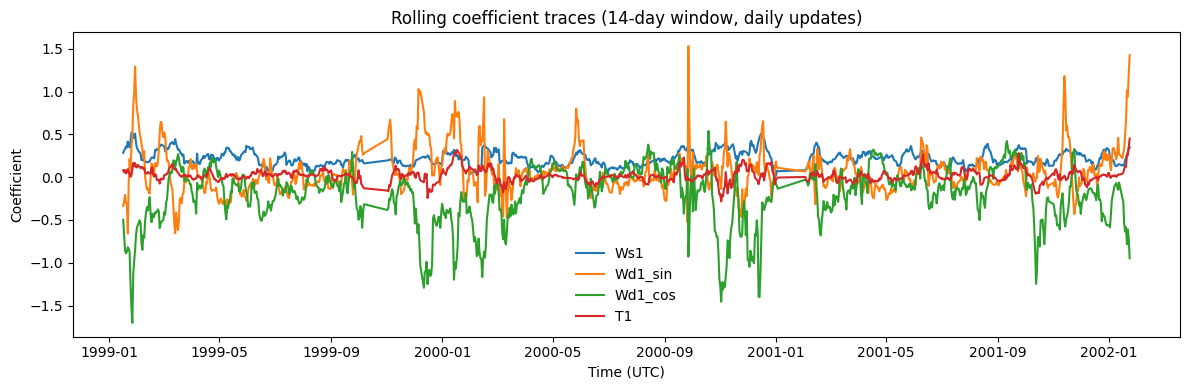

In [15]:

window = 24*14  # 14 days
step = 24       # estimate once per day for readability

coef_cols = [c for c in ["Ws1","Wd1_sin","Wd1_cos","T1"] if c in X_cols]
trace = {c: [] for c in coef_cols}
trace_t = []

for end in range(window, train_end, step):
    sub = work.iloc[end-window:end]
    X = sm.add_constant(sub[X_cols])
    y = sub["p"]
    m = sm.OLS(y, X).fit()
    trace_t.append(sub["t"].iloc[-1])
    for c in coef_cols:
        trace[c].append(m.params.get(c, np.nan))

plt.figure(figsize=(12,4))
for c in coef_cols:
    plt.plot(trace_t, trace[c], label=c)
plt.title("Rolling coefficient traces (14-day window, daily updates)")
plt.xlabel("Time (UTC)")
plt.ylabel("Coefficient")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


**Assumption (slow parameter drift / local linearity).** If coefficient traces evolve smoothly rather than jumping, a time-varying-parameter state-space model with recursive estimation is reasonable.

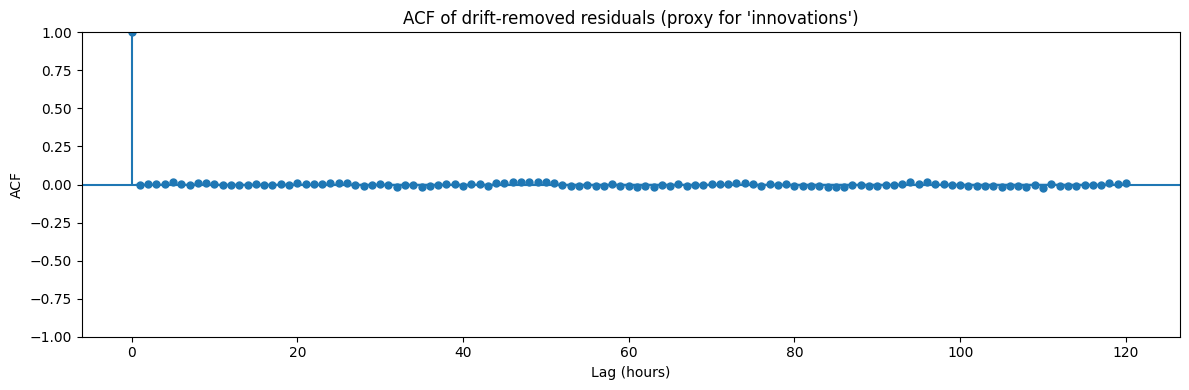

In [16]:

e = work["resid"].astype(float)
e_demean = e - e.rolling(24*7, min_periods=24*7).mean()  # remove slow drift

plt.figure(figsize=(12,4))
plot_acf(e_demean.dropna(), lags=120, ax=plt.gca())
plt.title("ACF of drift-removed residuals (proxy for 'innovations')")
plt.xlabel("Lag (hours)")
plt.ylabel("ACF")
plt.tight_layout()
plt.show()


**Assumption (innovations near-white noise).** If drift-removed residual ACF is mostly within bounds, innovation whiteness is more plausible under a state-space formulation.

### 3.3 Regime-switching / structural change

We look for breaks, variance regimes, and residual clustering suggesting that a single linear model may be insufficient.

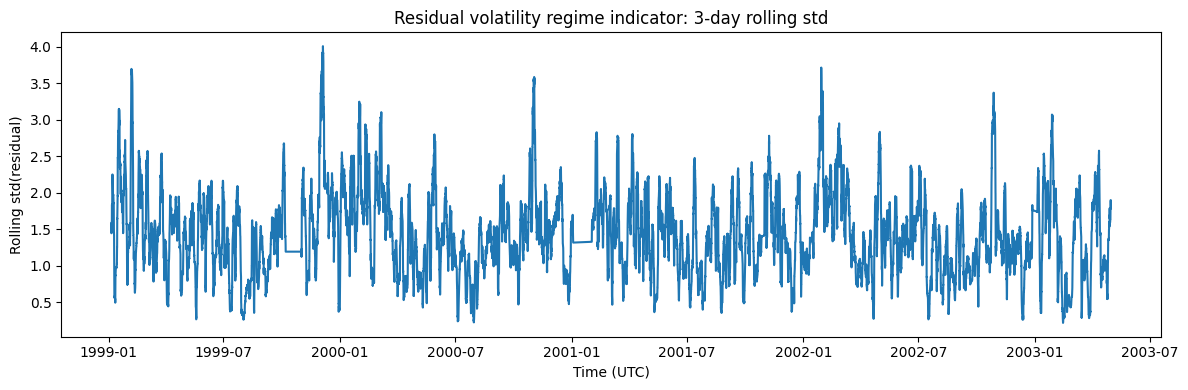

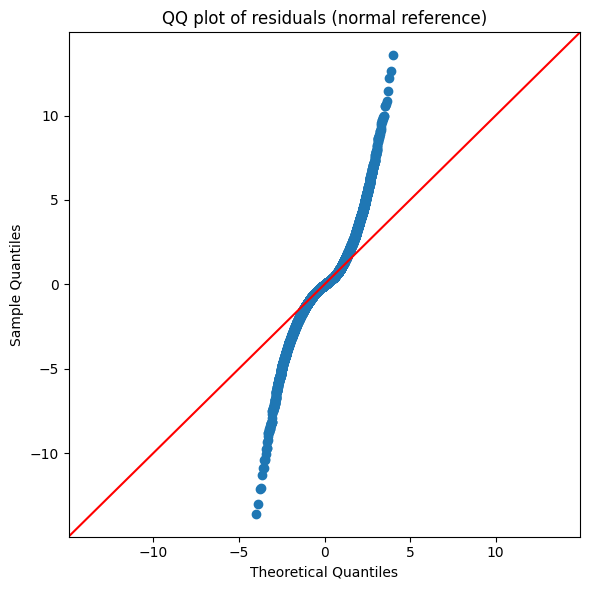

In [17]:

e = work["resid"].astype(float)
vol = e.rolling(24*3, min_periods=24*3).std()  # 3-day rolling std

plt.figure(figsize=(12,4))
plt.plot(work["t"], vol)
plt.title("Residual volatility regime indicator: 3-day rolling std")
plt.xlabel("Time (UTC)")
plt.ylabel("Rolling std(residual)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))
sm.qqplot(e.dropna(), line="45", ax=plt.gca())
plt.title("QQ plot of residuals (normal reference)")
plt.tight_layout()
plt.show()


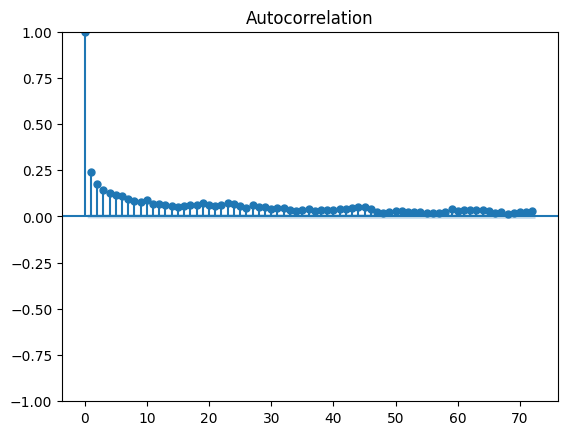

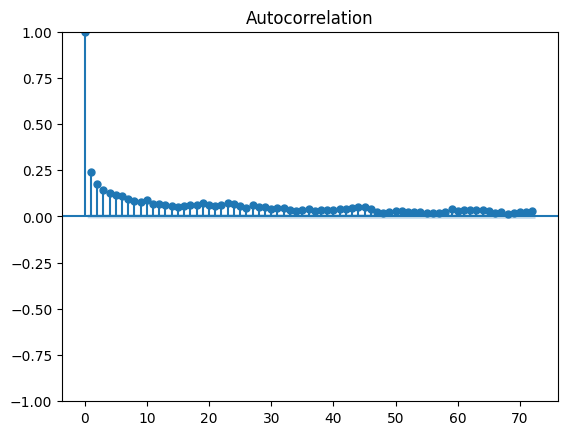

In [18]:
# ACF of squared residuals to confirm volatility clustering
from statsmodels.graphics.tsaplots import plot_acf
residuals = work["resid"].astype(float)
plot_acf(residuals**2, lags=72)

**Assumption (single-regime linear sufficiency).** If volatility clusters and QQ tails deviate strongly from normality, regime-switching or variance-regime modelling becomes justified.

## 4. Summary table (synthesis)

The table lists the most exam-relevant findings, the evidence used, and the modelling implication.

In [19]:

findings = [
    ("Strong persistence", "ACF slow decay; PACF short-lag peaks", "Include AR terms; validate residual whiteness"),
    ("Diurnal structure", "Mean(p) by hour-of-day", "Add diurnal term or allow time-varying parameters"),
    ("Seasonal drift", "LOWESS(p | toy) varies over year", "Seasonal terms or adaptive coefficients"),
    ("Nonlinear power curve", "LOWESS(p | Ws1) is curved", "Use nonlinear wind-speed features or piecewise effects"),
    ("Direction dependence", "Power curves differ by Wd1 bins", "Include circular direction features (sin/cos)"),
    ("Exogenous relevance", "Cross-correlation p vs Ws1", "ARX with Ws as primary driver"),
    ("Residual autocorrelation risk", "Residual ACF + Ljung–Box", "Increase dynamics / adaptivity if rejected"),
    ("Variance regimes", "Rolling std(resid) + ARCH test", "Consider regime switching / variance modelling"),
    ("Near-white innovations (after drift removal)", "ACF of drift-removed residuals", "State-space/Kalman innovation assumption more plausible"),
]
summary = pd.DataFrame(findings, columns=["Finding", "Evidence", "Assumption / Model implication"])
summary


,Finding,Evidence,Assumption / Model implication
0,Strong persistence,ACF slow decay; PACF short-lag peaks,Include AR terms; validate residual whiteness
1,Diurnal structure,Mean(p) by hour-of-day,Add diurnal term or allow time-varying parameters
2,Seasonal drift,LOWESS(p | toy) varies over year,Seasonal terms or adaptive coefficients
3,Nonlinear power curve,LOWESS(p | Ws1) is curved,Use nonlinear wind-speed features or piecewise...
4,Direction dependence,Power curves differ by Wd1 bins,Include circular direction features (sin/cos)
5,Exogenous relevance,Cross-correlation p vs Ws1,ARX with Ws as primary driver
6,Residual autocorrelation risk,Residual ACF + Ljung–Box,Increase dynamics / adaptivity if rejected
7,Variance regimes,Rolling std(resid) + ARCH test,Consider regime switching / variance modelling
8,Near-white innovations (after drift removal),ACF of drift-removed residuals,State-space/Kalman innovation assumption more ...
